<a href="https://colab.research.google.com/github/hamedtavakoli/MyColab/blob/main/SST_Cluster_WetDry_Linkage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⬇️ Step 1 — Setup & Authenticate

In [ ]:
!pip -q install earthengine-api geemap pandas numpy matplotlib scikit-learn scipy

import ee, geemap, pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from sklearn.linear_model import LinearRegression
from scipy.stats import f_oneway, kruskal


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.3 MB/s eta 0:00:00


In [ ]:

ee.Authenticate()
ee.Initialize(project='gcmcluster')

#⬇️ Step 2 — Define Region (insert your polygon)

Replace ROI_COORDS with your polygon (lon,lat). You can paste any GeoJSON-style ring.

In [ ]:
# ---- Build baseline monthly totals and 12-month climatology (1982–2012) ----
BASE_START = '1982-01-01'
BASE_END   = '2011-12-31'

# 0) CONFIG: region name and lag window
REGION_NAME = "Iran"       # <-- change this if you analyse another region
MAX_LAG     = 18           # +/- months for lag analysis

# === Step 1: Region of Interest (ROI) — Iran ===
# We’ll try two admin boundary sources and union the matches.

def get_country_geometry(country_name='Iran'):
    # Source 1: US DOS LSIB (simple)
    lsib = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017') \
        .filter(ee.Filter.eq('country_na', country_name))
    if lsib.size().getInfo() > 0:
        return lsib.geometry()

    # Source 2: FAO GAUL level 0 (country names vary)
    gaul = ee.FeatureCollection('FAO/GAUL/2015/level0')
    # Try common GAUL name variants for Iran
    variants = [
        'Iran',
        'Iran (Islamic Republic of)',
        'Iran, Islamic Republic of'
    ]
    fc = None
    for v in variants:
        fcv = gaul.filter(ee.Filter.eq('ADM0_NAME', v))
        if fcv.size().getInfo() > 0:
            fc = fcv
            break
    if fc is not None:
        return fc.geometry()

    raise ValueError("Could not find Iran in the admin boundary sources.")

roi = get_country_geometry('Iran')

# Date range for CHIRPS Monthly (used in Step 2)
START = '1982-01-01'
END   = '2011-12-31'

# Quick map sanity check (Colab)
m = geemap.Map()
m.addLayer(roi, {'color': 'red'}, 'Iran ROI')
m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

#⬇️ Step 3 — Rainfall (CHIRPS Monthly) + Climatology + Anomalies

In [ ]:
# === Step 2 : Rainfall from CHIRPS Daily → Monthly totals, Climatology (1981–2010), Anomalies ===
# Dataset: UCSB-CHG/CHIRPS/DAILY — precipitation in mm/day
CHIRPS_DAILY = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').select('precipitation')

# ---- Helpers to build monthly sums from daily ----
import pandas as pd

def _ee_month_starts(start_str, end_str):
    """Return ee.List of ee.Date month starts from START..END (inclusive of START)."""
    # Build on client then cast to ee.List of ee.Date
    dts = pd.date_range(start=start_str, end=end_str, freq='MS')
    return ee.List([ee.Date(str(d.date())) for d in dts])

def daily_to_monthly_sum(ic, start_str, end_str):
    """
    Convert a daily ImageCollection (mm/day) to a monthly-sum ImageCollection (mm/month).
    Each monthly image has property 'system:time_start' at the first day of that month.
    """
    month_starts = _ee_month_starts(start_str, end_str)
    def _one_month(d):
        d = ee.Date(d)
        msum = ic.filterDate(d, d.advance(1, 'month')).sum() \
                 .rename('pr_month') \
                 .set({'system:time_start': d.millis(),
                       'year': d.get('year'),
                       'month': d.get('month')})
        return msum
    return ee.ImageCollection.fromImages(month_starts.map(_one_month))

baseline_monthly_ic = daily_to_monthly_sum(CHIRPS_DAILY, BASE_START, BASE_END)

def build_monthly_clim_from_monthly(monthly_ic):
    """Return 12-image climatology (mean monthly total) with band 'pr_clim' and property 'month'=1..12."""
    months = ee.List.sequence(1, 12)
    def _clim(m):
        m = ee.Number(m)
        mean_m = monthly_ic.filter(ee.Filter.calendarRange(m, m, 'month')) \
                           .mean().rename('pr_clim') \
                           .set({'month': m})
        return mean_m
    return ee.ImageCollection.fromImages(months.map(_clim))

CHIRPS_CLIM = build_monthly_clim_from_monthly(baseline_monthly_ic)  # 12 images

# ---- Build observed monthly totals for your analysis window (START..END) ----
obs_monthly_ic = daily_to_monthly_sum(CHIRPS_DAILY, START, END)  # uses your earlier START/END

# ---- Compute anomalies: observed monthly total minus climatological mean for that calendar month ----
def add_monthly_anomaly(img):
    m = ee.Number(img.get('month'))
    clim = CHIRPS_CLIM.filter(ee.Filter.eq('month', m)).first().select('pr_clim')
    anom = img.select('pr_month').subtract(clim).rename('pr_anom')
    # keep metadata + time
    return img.addBands(anom).set({'system:time_start': img.get('system:time_start')})

obs_with_anom = obs_monthly_ic.map(add_monthly_anomaly)

# ---- Reduce over ROI to monthly series (mean over polygon). You can switch Reducer to sum if desired. ----
def series_from_monthly(ic, band_name):
    def _reduce(img):
        val = img.select(band_name).reduceRegion(
            reducer=ee.Reducer.mean(),  # or ee.Reducer.sum() if you prefer totals over the polygon area
            geometry=roi,               # 'roi' defined in your Iran cell
            scale=10000,
            maxPixels=1e13
        )
        return ee.Feature(None, {
            'date': ee.Date(img.get('system:time_start')).format('YYYY-MM-01'),
            band_name: val.get(band_name)
        })
    fc = ee.FeatureCollection(ic.map(_reduce))
    # MANUAL CONVERSION TO PANDAS DATAFRAME
    data = fc.getInfo()['features']
    df_data = []
    for f in data:
        df_data.append(f['properties'])
    return pd.DataFrame(df_data).dropna()


rain_obs_df  = series_from_monthly(obs_monthly_ic, 'pr_month')   # mm/month (mean over ROI)
rain_anom_df = series_from_monthly(obs_with_anom,   'pr_anom')   # anomaly mm/month

# ---- Merge & prepare dataframe ----
rain = pd.merge(rain_obs_df, rain_anom_df, on='date', how='inner')
rain['date'] = pd.to_datetime(rain['date'])
rain.sort_values('date', inplace=True)

# Optional: standardise anomalies
rain['pr_anom_z'] = (rain['pr_anom'] - rain['pr_anom'].mean()) / rain['pr_anom'].std(ddof=0)

print('Rows:', len(rain))
print(rain.head())

Rows: 360
        date   pr_month    pr_anom  pr_anom_z
0 1982-01-01  52.011109  13.161518   1.823192
1 1982-02-01  59.749654  24.605241   3.408427
2 1982-03-01  51.427492  14.835843   2.055126
3 1982-04-01  18.351324  -7.057925  -0.977695
4 1982-05-01  14.426384   2.159228   0.299106


#⬇️ Step 4 — Load SOM BMUs, join to rainfall series

In [ ]:
# === Step 3: Join SOM clusters with rainfall ===
# Expect CSV with:
# - comment metadata lines starting with '#'
# - a header line: date,node_id
# - data lines: YYYY-MM-DD,<int>

from google.colab import drive
import pandas as pd
import os

# 1) Mount Drive (warning about already mounted is fine)
drive.mount('/content/drive', force_remount=False)

# 2) BMU file path (you can later swap this to input() if you want it interactive)
bmu_path = '/content/drive/MyDrive/SST_SOM/SOM_monthly_1982-01-01_2011-12-31_deg4.0_SOM4x4_it20000_20251114T051025Z/som_bmu_timeseries.csv'

# 3) Sanity check
if not os.path.exists(bmu_path):
    raise FileNotFoundError(f"File not found: {bmu_path}")

# 4) Read CSV, skipping metadata lines that start with '#'
bmu = pd.read_csv(
    bmu_path,
    comment='#',      # <-- this ignores all the header lines you showed
    engine='python'   # more tolerant parser (optional but safe)
)

print("Loaded BMU file:")
print(bmu.head())

# 5) Ensure date is monthly and aligned
bmu['date'] = pd.to_datetime(bmu['date']).dt.to_period('M').dt.to_timestamp()

# 6) Align ranges and merge with rainfall dataframe `rain`
df = pd.merge(rain, bmu, on='date', how='inner')
df.dropna(subset=['node_id', 'pr_anom'], inplace=True)
df['node_id'] = df['node_id'].astype(int)

print(df[['date','node_id','pr_month','pr_anom','pr_anom_z']].head())
print('Merged length:', len(df))


Mounted at /content/drive
Loaded BMU file:
         date  node_id
0  1982-01-01       14
1  1982-02-01       15
2  1982-03-01       15
3  1982-04-01       11
4  1982-05-01        7
        date  node_id   pr_month    pr_anom  pr_anom_z
0 1982-01-01       14  52.011109  13.161518   1.823192
1 1982-02-01       15  59.749654  24.605241   3.408427
2 1982-03-01       15  51.427492  14.835843   2.055126
3 1982-04-01       11  18.351324  -7.057925  -0.977695
4 1982-05-01        7  14.426384   2.159228   0.299106
Merged length: 360


#⬇️ Step 5 — Stats — composites, ANOVA/Kruskal, R², MI

Per-cluster rainfall composites:
     node_id   n  pr_anom_mean  pr_anom_std  pr_anom_z_mean
0         0  24 -3.723206e-02     0.372494   -5.157549e-03
1         1  14 -8.829583e-02     0.611021   -1.223113e-02
2         2   9  3.869493e-01     1.539303    5.360192e-02
3         3   7  1.379421e+00     3.283905    1.910834e-01
4         4  36  2.482137e-02     0.845091    3.438366e-03
5         5  16  7.725885e-02     0.701598    1.070224e-02
6         6  21 -1.658354e-01     1.061710   -2.297225e-02
7         7  23 -4.198237e-01     3.600455   -5.815583e-02
8         8  30 -5.329071e-16     3.345058   -2.886580e-16
9         9   7  3.902710e+00     9.394506    5.406206e-01
10       10  23  5.685999e-01    10.973280    7.876497e-02
11       11  30 -7.727152e-15    10.210291   -1.265654e-15
12       12  23 -1.187781e+00     7.222614   -1.645367e-01
13       13   7 -1.868257e+00    12.886007   -2.587992e-01
14       14  30  1.681618e-14    10.399033    2.124227e-15
15       15  60  3.720

<Figure size 800x500 with 0 Axes>

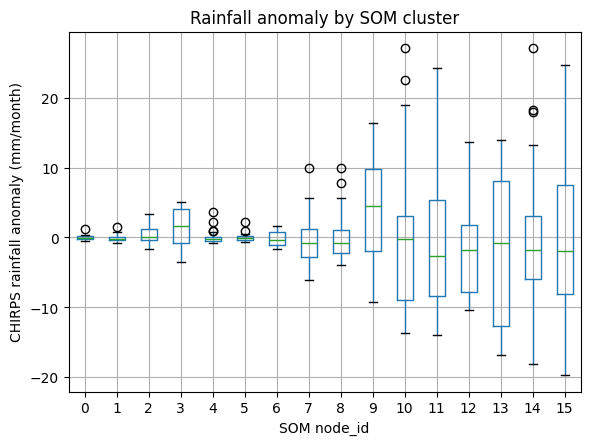

In [ ]:
# === Step 4: Quantify relationships ===

# 4.1 Per-cluster composites (mean rainfall anomaly in your ROI)
cluster_stats = df.groupby('node_id').agg(
    n=('pr_anom', 'size'),
    pr_anom_mean=('pr_anom', 'mean'),
    pr_anom_std=('pr_anom', 'std'),
    pr_anom_z_mean=('pr_anom_z', 'mean')
).reset_index().sort_values('node_id')
print('Per-cluster rainfall composites:\n', cluster_stats)

# 4.2 ANOVA (parametric) and Kruskal-Wallis (nonparametric)
groups = [g['pr_anom'].values for _, g in df.groupby('node_id')]
if len(groups) > 1:
    anova_F, anova_p = f_oneway(*groups)
    kw_H, kw_p = kruskal(*groups)
    print(f'ANOVA:   F={anova_F:.3f}, p={anova_p:.3g}')
    print(f'Kruskal: H={kw_H:.3f}, p={kw_p:.3g}')
else:
    print('Only one cluster present in the merged data; ANOVA/Kruskal not applicable.')

# 4.3 R²: rainfall anomaly explained by cluster membership (one-hot encoder)
X = pd.get_dummies(df['node_id'], prefix='c', drop_first=True)  # baseline class absorbed
y = df['pr_anom'].values
if X.shape[1] > 0:
    r2 = LinearRegression().fit(X, y).score(X, y)
    print(f'Explained variance (R²) by cluster membership: {r2:.3f}')
else:
    print('Only one cluster present; R² not defined.')

# 4.4 Mutual Information (captures any nonlinear association)
# (Discretize rainfall anomaly into quantiles to make MI robust)
q = pd.qcut(df['pr_anom'], q=5, labels=False, duplicates='drop')  # quintiles
mi = mutual_info_score(df['node_id'], q)
print(f'Mutual Information (node_id vs rainfall anomaly quintile): {mi:.3f}')

# 4.5 (Optional) simple boxplot of rainfall anomaly by cluster
plt.figure(figsize=(8,5))
df.boxplot(column='pr_anom', by='node_id')
plt.title('Rainfall anomaly by SOM cluster')
plt.suptitle('')
plt.xlabel('SOM node_id')
plt.ylabel('CHIRPS rainfall anomaly (mm/month)')
plt.show()


#⬇️ Step 6 — Exploring Lag Relationships (1 to 18 months)

Top result by lag (|r| and node):
     best_|r|     node
lag                   
-18  0.143063   node_5
-17  0.161179   node_2
-16  0.168190   node_3
-15  0.097817   node_5
-14  0.110520   node_2
-13  0.157275   node_3
-12  0.089863  node_13
-11  0.115523  node_13
-10  0.150661  node_13
-9   0.150637   node_9
-8   0.130967  node_13
-7   0.137446   node_1
-6   0.153486   node_1
-5   0.138733   node_2
-4   0.146184   node_2
-3   0.149760   node_3
-2   0.074694   node_3
-1   0.128379   node_3
 0   0.076130   node_9
 1   0.066386  node_13
 2   0.149101  node_13
 3   0.150817   node_9
 4   0.165734  node_13
 5   0.165882   node_9
 6   0.163825   node_5
 7   0.090820   node_5
 8   0.081437   node_5
 9   0.150876   node_3
 10  0.090498   node_2
 11  0.166018   node_3
 12  0.072842   node_9
 13  0.046981   node_9
 14  0.128601  node_13
 15  0.128584   node_9
 16  0.157615  node_13
 17  0.157776   node_9
 18  0.166358   node_5


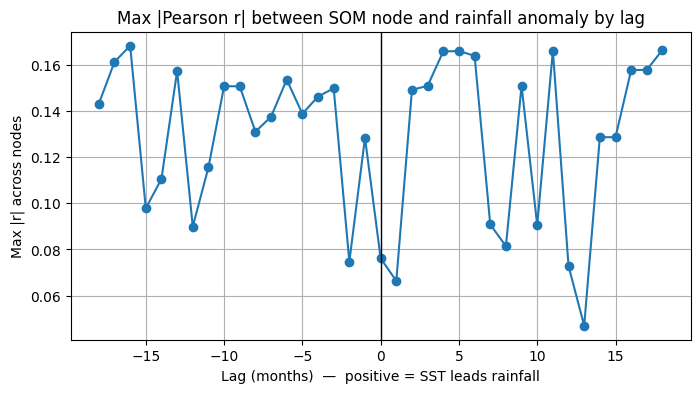


Strongest link: node_3 at lag -16 months, r = 0.168

Correlations by node at lag -16:
node_3     0.168190
node_2     0.105896
node_1     0.057060
node_11    0.051913
node_0     0.049019
node_12    0.003890
node_14    0.001928
node_10    0.001687
node_8     0.000311
node_9    -0.001824
node_13   -0.002363
node_15   -0.009754
node_4    -0.050756
node_5    -0.053029
node_6    -0.100551
node_7    -0.109889
Name: -16, dtype: float64


In [ ]:
# === Step 5 (fixed): Lag correlations between SOM nodes and rainfall anomaly ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure sorted monthly index
d = df[['date','node_id','pr_anom_z']].copy()
d['date'] = pd.to_datetime(d['date'])
d = d.sort_values('date').set_index('date')

# One-hot (binary) columns for node membership (one active node per month)
nodes = pd.get_dummies(d['node_id'], prefix='node')  # shape (T, K)
rain  = d['pr_anom_z']                               # shape (T,)

# Helper: correlation with lag using pandas .shift
# Positive lag L means: SST node at t relates to rainfall at t+L
def corr_with_lag(node_series, rain_series, L):
    if L > 0:
        r = rain_series.shift(-L)  # align rain at t+L with node at t
        n = node_series
    elif L < 0:
        r = rain_series.shift(-L)  # align rain at t-abs(L) with node at t (rain leads)
        n = node_series
    else:
        r = rain_series
        n = node_series
    aligned = pd.concat([n, r], axis=1).dropna()
    if aligned.shape[0] < 6:  # too few points to be meaningful
        return np.nan
    return aligned.iloc[:,0].corr(aligned.iloc[:,1])


lags = list(range(-MAX_LAG, MAX_LAG+1))

# Per-node correlations for each lag
per_lag_results = []
for L in lags:
    row = {'lag': L}
    for col in nodes.columns:
        row[col] = corr_with_lag(nodes[col], rain, L)
    per_lag_results.append(row)

lag_corr_df = pd.DataFrame(per_lag_results).set_index('lag')  # index=lag, columns=node_*
# Aggregate: best absolute correlation per lag and which node achieves it
best_abs_r = lag_corr_df.abs().max(axis=1)
best_node  = lag_corr_df.abs().idxmax(axis=1)

print("Top result by lag (|r| and node):")
print(pd.DataFrame({'best_|r|': best_abs_r, 'node': best_node}))

# Plot: max |r| vs lag
plt.figure(figsize=(8,4))
plt.plot(best_abs_r.index, best_abs_r.values, marker='o')
plt.axvline(0, color='k', lw=1)
plt.title('Max |Pearson r| between SOM node and rainfall anomaly by lag')
plt.xlabel('Lag (months)  —  positive = SST leads rainfall')
plt.ylabel('Max |r| across nodes')
plt.grid(True)
plt.show()

# Report the single strongest node/lag pair
global_best_lag = best_abs_r.idxmax()
global_best_node = best_node.loc[global_best_lag]
global_best_r = lag_corr_df.loc[global_best_lag, global_best_node]
print(f"\nStrongest link: {global_best_node} at lag {global_best_lag:+d} months, r = {global_best_r:.3f}")

# Optional: show the full per-node correlation table for the best lag
print(f"\nCorrelations by node at lag {global_best_lag:+d}:")
print(lag_corr_df.loc[global_best_lag].sort_values(ascending=False))


#⬇️ Step 7 — Saveing the results

In [ ]:
# === Save Step 4 + Step 5 results in one go ===
from google.colab import drive
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mutual_info_score
from scipy.stats import f_oneway, kruskal


# 1) Mount Drive
drive.mount('/content/drive', force_remount=False)

# 2) Create experiment folder name
timestamp = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
root_dir  = "/content/drive/MyDrive/SST_SOM_WetDry_Analysis"
run_name  = f"{REGION_NAME}_SST_SOM_WetDry_{timestamp}"
EXPORT_DIR = os.path.join(root_dir, run_name)
os.makedirs(EXPORT_DIR, exist_ok=True)

print("Saving results to:", EXPORT_DIR)

# ---------------------------------------------------------------------
# STEP 4: CONTEMPORANEOUS RELATIONSHIP (CLUSTER vs RAINFALL)
# ---------------------------------------------------------------------

# Ensure df exists
assert 'df' in globals(), "Dataframe `df` (rainfall + BMUs) not found. Run merge cell first."

# Per-cluster composites
cluster_stats = df.groupby('node_id').agg(
    n=('pr_anom', 'size'),
    pr_anom_mean=('pr_anom', 'mean'),
    pr_anom_std=('pr_anom', 'std'),
    pr_anom_z_mean=('pr_anom_z', 'mean')
).reset_index().sort_values('node_id')

# ANOVA / Kruskal
groups = [g['pr_anom'].values for _, g in df.groupby('node_id')]
anova_F = anova_p = kw_H = kw_p = None
if len(groups) > 1:
    anova_F, anova_p = f_oneway(*groups)
    kw_H, kw_p = kruskal(*groups)

# R² (cluster membership -> rainfall anomaly)
X = pd.get_dummies(df['node_id'], prefix='c', drop_first=True)
y = df['pr_anom'].values
r2 = None
if X.shape[1] > 0:
    r2 = LinearRegression().fit(X, y).score(X, y)

# Mutual Information (node vs rainfall anomaly quintiles)
rain_quintile = pd.qcut(df['pr_anom'], q=5, labels=False, duplicates='drop')
mi = mutual_info_score(df['node_id'], rain_quintile)

# Save tables
joined_csv   = os.path.join(EXPORT_DIR, "step4_rainfall_SOM_joined_timeseries.csv")
clusters_csv = os.path.join(EXPORT_DIR, "step4_cluster_rainfall_composites.csv")
stats_json   = os.path.join(EXPORT_DIR, "step4_rainfall_SOM_stats.json")

df[['date', 'node_id', 'pr_month', 'pr_anom', 'pr_anom_z']].to_csv(joined_csv, index=False)
cluster_stats.to_csv(clusters_csv, index=False)

stats_payload = {
    "region": REGION_NAME,
    "n_records": int(len(df)),
    "n_clusters": int(df['node_id'].nunique()),
    "anova": None if anova_F is None else {"F": float(anova_F), "p": float(anova_p)},
    "kruskal": None if kw_H is None else {"H": float(kw_H), "p": float(kw_p)},
    "r2_explained_variance": None if r2 is None else float(r2),
    "mutual_information_node_vs_rain_quintile": float(mi)
}
with open(stats_json, "w") as f:
    json.dump(stats_payload, f, indent=2)

# Plots for Step 4
# Boxplot
plt.figure(figsize=(9, 5))
df.boxplot(column="pr_anom", by="node_id")
plt.title(f"{REGION_NAME} rainfall anomaly by SOM cluster")
plt.suptitle("")
plt.xlabel("SOM node_id")
plt.ylabel("CHIRPS monthly anomaly (mm)")
boxplot_png = os.path.join(EXPORT_DIR, "step4_boxplot_rain_anom_by_cluster.png")
plt.tight_layout()
plt.savefig(boxplot_png, dpi=160)
plt.close()

# Bar of mean anomaly per cluster
plt.figure(figsize=(9, 5))
plt.bar(cluster_stats["node_id"].astype(str), cluster_stats["pr_anom_mean"])
plt.title(f"{REGION_NAME}: mean rainfall anomaly by SOM cluster")
plt.xlabel("SOM node_id")
plt.ylabel("Mean CHIRPS anomaly (mm/month)")
bar_png = os.path.join(EXPORT_DIR, "step4_bar_mean_anom_by_cluster.png")
plt.tight_layout()
plt.savefig(bar_png, dpi=160)
plt.close()

# ---------------------------------------------------------------------
# STEP 5: LAG-CORRELATION ANALYSIS (±MAX_LAG months)
# ---------------------------------------------------------------------

# Prepare monthly series
d = df[['date', 'node_id', 'pr_anom_z']].copy()
d['date'] = pd.to_datetime(d['date'])
d = d.sort_values('date').set_index('date')

nodes = pd.get_dummies(d['node_id'], prefix='node')
rain_z = d['pr_anom_z']

def corr_with_lag(node_series, rain_series, L):
    """Pearson r between node activity and rainfall anomaly at lag L.
       Positive L: SST node leads rainfall by L months."""
    if L > 0:
        r = rain_series.shift(-L)
        n = node_series
    elif L < 0:
        r = rain_series.shift(-L)
        n = node_series
    else:
        r = rain_series
        n = node_series
    aligned = pd.concat([n, r], axis=1).dropna()
    return aligned.iloc[:, 0].corr(aligned.iloc[:, 1]) if len(aligned) > 6 else np.nan

lags = range(-MAX_LAG, MAX_LAG + 1)
records = []
for L in lags:
    rec = {"lag": L}
    for col in nodes.columns:
        rec[col] = corr_with_lag(nodes[col], rain_z, L)
    records.append(rec)

lag_corr_df = pd.DataFrame(records).set_index("lag")

best_abs_r = lag_corr_df.abs().max(axis=1)
best_node  = lag_corr_df.abs().idxmax(axis=1)

# Save lag tables
lag_corr_csv   = os.path.join(EXPORT_DIR, "step5_SOM_rainfall_lag_correlations.csv")
lag_summary_csv = os.path.join(EXPORT_DIR, "step5_SOM_lag_summary.csv")

lag_corr_df.to_csv(lag_corr_csv)
lag_summary = pd.DataFrame({
    "lag": best_abs_r.index,
    "best_|r|": best_abs_r.values,
    "best_node": best_node.values
}).set_index("lag")
lag_summary.to_csv(lag_summary_csv)

# Lag plot
plt.figure(figsize=(9, 4))
plt.plot(best_abs_r.index, best_abs_r.values, marker="o")
plt.axvline(0, color="k", lw=1)
plt.title(f"{REGION_NAME}: max |r| between SOM node and rainfall anomaly (±{MAX_LAG} months)")
plt.xlabel("Lag (months) — positive = SST leads rainfall")
plt.ylabel("Max |r| across nodes")
plt.grid(True)
lag_plot_png = os.path.join(EXPORT_DIR, "step5_lag_correlation_plot.png")
plt.tight_layout()
plt.savefig(lag_plot_png, dpi=160)
plt.close()

# Summary JSON for lag analysis
global_best_lag  = best_abs_r.idxmax()
global_best_node = best_node.loc[global_best_lag]
global_best_r    = lag_corr_df.loc[global_best_lag, global_best_node]

lag_summary_json = {
    "region": REGION_NAME,
    "max_abs_r_overall": float(best_abs_r.max()),
    "best_lag_months": int(global_best_lag),
    "best_node": str(global_best_node),
    "r_value": float(global_best_r),
    "n_lags_tested": int(len(best_abs_r)),
    "comment": "Positive lag means SST pattern leads rainfall (predictive direction)."
}
lag_json_path = os.path.join(EXPORT_DIR, "step5_SOM_lag_summary_stats.json")
with open(lag_json_path, "w") as f:
    json.dump(lag_summary_json, f, indent=2)

# ---------------------------------------------------------------------
# README for the whole experiment
# ---------------------------------------------------------------------
readme_path = os.path.join(EXPORT_DIR, "README_Experiment.txt")
with open(readme_path, "w") as f:
    f.write(
        f"SST–SOM Wet/Dry Analysis — {REGION_NAME}\n"
        "========================================\n"
        f"Experiment folder: {run_name}\n"
        f"Region: {REGION_NAME}\n"
        f"Records merged (df): {len(df)}\n"
        f"Unique SOM clusters: {df['node_id'].nunique()}\n\n"
        "STEP 4 (no lag):\n"
        f"- ANOVA: {stats_payload['anova']}\n"
        f"- Kruskal: {stats_payload['kruskal']}\n"
        f"- R² explained variance: {stats_payload['r2_explained_variance']}\n"
        f"- Mutual information: {stats_payload['mutual_information_node_vs_rain_quintile']}\n\n"
        "STEP 5 (lag analysis):\n"
        f"- Max |r|: {lag_summary_json['max_abs_r_overall']:.3f}\n"
        f"- Best lag (months): {lag_summary_json['best_lag_months']:+d}\n"
        f"- Best node: {lag_summary_json['best_node']}\n"
        f"- r at best lag/node: {lag_summary_json['r_value']:.3f}\n\n"
        "Saved files:\n"
        f"- {os.path.basename(joined_csv)} — joined monthly time series.\n"
        f"- {os.path.basename(clusters_csv)} — per-cluster rainfall composites.\n"
        f"- {os.path.basename(stats_json)} — Step 4 stats.\n"
        f"- {os.path.basename(boxplot_png)}, {os.path.basename(bar_png)} — Step 4 plots.\n"
        f"- {os.path.basename(lag_corr_csv)}, {os.path.basename(lag_summary_csv)} — lag correlation matrices.\n"
        f"- {os.path.basename(lag_plot_png)} — lag correlation curve.\n"
        f"- {os.path.basename(lag_json_path)} — Step 5 summary stats.\n"
    )

print("✅ All Step 4 + Step 5 results saved to:", EXPORT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving results to: /content/drive/MyDrive/SST_SOM_WetDry_Analysis/Iran_SST_SOM_WetDry_20251114T065653Z
✅ All Step 4 + Step 5 results saved to: /content/drive/MyDrive/SST_SOM_WetDry_Analysis/Iran_SST_SOM_WetDry_20251114T065653Z


<Figure size 900x500 with 0 Axes>